# 13_get_sequence_encodings

Run sequence encoding generation using `agentic_protein_design.steps.get_sequence_encodings`.
This notebook reflects the current step API (`root_key`, `data_subfolder`, `encodings_subfolder`).

## Python Path Setup

In [1]:
from pathlib import Path
import sys

# Section 1: Resolve repo root from either project root or notebooks/ cwd.
cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name == "notebooks" else cwd

# Section 2: Add repo and src roots to sys.path for imports.
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
src_root = repo_root / "src"
if src_root.exists() and str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

print("repo_root:", repo_root)
print("src_root:", src_root)


repo_root: /Users/charmainechia/Documents/projects/agentic-protein-design
src_root: /Users/charmainechia/Documents/projects/agentic-protein-design/src


## Imports

In [2]:
import importlib
import agentic_protein_design.steps.get_sequence_encodings as enc_step
from project_config.variables import address_dict

enc_step = importlib.reload(enc_step)

default_user_inputs = enc_step.default_user_inputs
parse_sequence_input = enc_step.parse_sequence_input
split_feature_sets = enc_step.split_feature_sets
get_sequence_encodings = enc_step.get_sequence_encodings


## User Inputs

In [4]:
user_inputs = default_user_inputs()

# Section 1: Configure output root and subfolders.
user_inputs["root_key"] = 'ECOHARVEST' # "examples" # "ppk2-hmo" #
user_inputs["data_subfolder"] = "" # "ET096_R1-2" #
user_inputs["encodings_subfolder"] = "encodings/"
filename = None # "ET096_R1-2.csv" #
user_inputs["filename_prefix"] = filename.split('.')[0] + "_"  if filename is not None else ""

# Section 2: Configure sequence input source.
# Use an absolute path for notebook portability.
user_inputs["sequence_input"] = None
# data_root = (repo_root / Path(address_dict[user_inputs["root_key"]])).resolve()
# user_inputs["sequence_input"] = str(
#     data_root / "expdata" / user_inputs["data_subfolder"] / filename
# )

# Section 3: Configure column names and optional base sequence fallback.
user_inputs["sequence_col"] = "sequence"
user_inputs["sequence_base_col"] = "sequence_base"
user_inputs["mutation_col"] = "mutations"
# user_inputs["sequence_base"] = None
user_inputs["sequence_base"] = 'MVPIKRQSNSTVDSLPPLIPSRTSAPSSSPSTTDPEAPAMSRNGPLPSDVETKYGMALNATSYPDSVVQAMSIDGGIRAATSQEINELTYYTTLSANSYCRTVIPGATWDCIHCDATEDLKIIKTWSTLIYDTNAMVARGDSEKTIYIVFRGSSSIRNWIADLTFVPVSYPPVSGTKVHKGFLDSYGEVQNELVATVLDQFKQYPSYKVAVTGHSLGGATALLCALDLYQREEGLSSSNLFLYTQGQPRVGDPAFANYVVSTGIPYRRTVNERDIVPHLPPAAFGFLHAGEEYWITDNSPETVQVCTSDLETSDCSNSIVPFTSVLDHLSYFGINTGLCT'

# Section 4: Configure feature sets.
# Default: FEATURE_SETS_DEFAULT from project_config/feature_registry.py
# user_inputs["feature_sets"] = None
# Example explicit list:
user_inputs["feature_sets"] = [
    # "one_hot",
    # "georgiev",
    # "esm2-650m_LLR",
    # "esm2-650m_meanPLL",
    # "esm2-650m_per_residue",
    # "esm2-650m_mean_pooled",
    # "esmc-600m_LLR",
    # "esm2-650m_meanPLL",
    # "esmc-600m_per_residue",
    # "esmc-600m_mean_pooled",
    "poet2_LLR",
    # "poet2_meanPLL",
    # "poet2_per_residue",
    # "poet2_mean_pooled",
    # "poet2_svd_pooled",
]

# Section 5: Optional runtime controls.
user_inputs["get_embeddings_for_seq_base"] = False
user_inputs["classical_max_length"] = None
user_inputs["marginal_type"] = "wt" # 'masked' #
user_inputs["llr_cache_vect_filename_prefix"] = 'RML_' # 'ET096_' # 'ppk2_' #
user_inputs["resave_llr_cache_if_found"] = False
user_inputs["mutations_sep"] = "+"
user_inputs["layers"] = {'esm2-650m': [33], 'esmc-600m': [36], 'poet2':[12]}
user_inputs["n_components"] = 1024
user_inputs["sample_mutants_for_svd"] = False
user_inputs["svd_data_reduction"] = None
user_inputs["batch_size"] = 4
user_inputs["device"] = None

user_inputs


{'root_key': 'ECOHARVEST',
 'data_subfolder': '',
 'encodings_subfolder': 'encodings/',
 'filename_prefix': '',
 'sequence_input': None,
 'sequence_col': 'sequence',
 'sequence_base_col': 'sequence_base',
 'mutation_col': 'mutations',
 'sequence_base': 'MVPIKRQSNSTVDSLPPLIPSRTSAPSSSPSTTDPEAPAMSRNGPLPSDVETKYGMALNATSYPDSVVQAMSIDGGIRAATSQEINELTYYTTLSANSYCRTVIPGATWDCIHCDATEDLKIIKTWSTLIYDTNAMVARGDSEKTIYIVFRGSSSIRNWIADLTFVPVSYPPVSGTKVHKGFLDSYGEVQNELVATVLDQFKQYPSYKVAVTGHSLGGATALLCALDLYQREEGLSSSNLFLYTQGQPRVGDPAFANYVVSTGIPYRRTVNERDIVPHLPPAAFGFLHAGEEYWITDNSPETVQVCTSDLETSDCSNSIVPFTSVLDHLSYFGINTGLCT',
 'feature_sets': ['poet2_LLR'],
 'get_embeddings_for_seq_base': False,
 'classical_max_length': None,
 'marginal_type': 'wt',
 'llr_cache_vect_filename_prefix': 'RML_',
 'resave_llr_cache_if_found': False,
 'mutations_sep': '+',
 'layers': {'esm2-650m': [33], 'esmc-600m': [36], 'poet2': [12]},
 'n_components': 1024,
 'sample_mutants_for_svd': False,
 'svd_data_reduction': None,
 'batch_size': 4,
 'de

## Run Step

sequence_input: 
Obtaining LLR scores for poet2...
[resolve_llr_cache_paths] vect cache NOT FOUND: /Users/charmainechia/Documents/projects/ECOHARVEST/encodings/LLR/RML_poet2_LLR_vect.csv
Prompt ID: 64ab8ca9-ce32-4514-a407-bfa4ba980aae


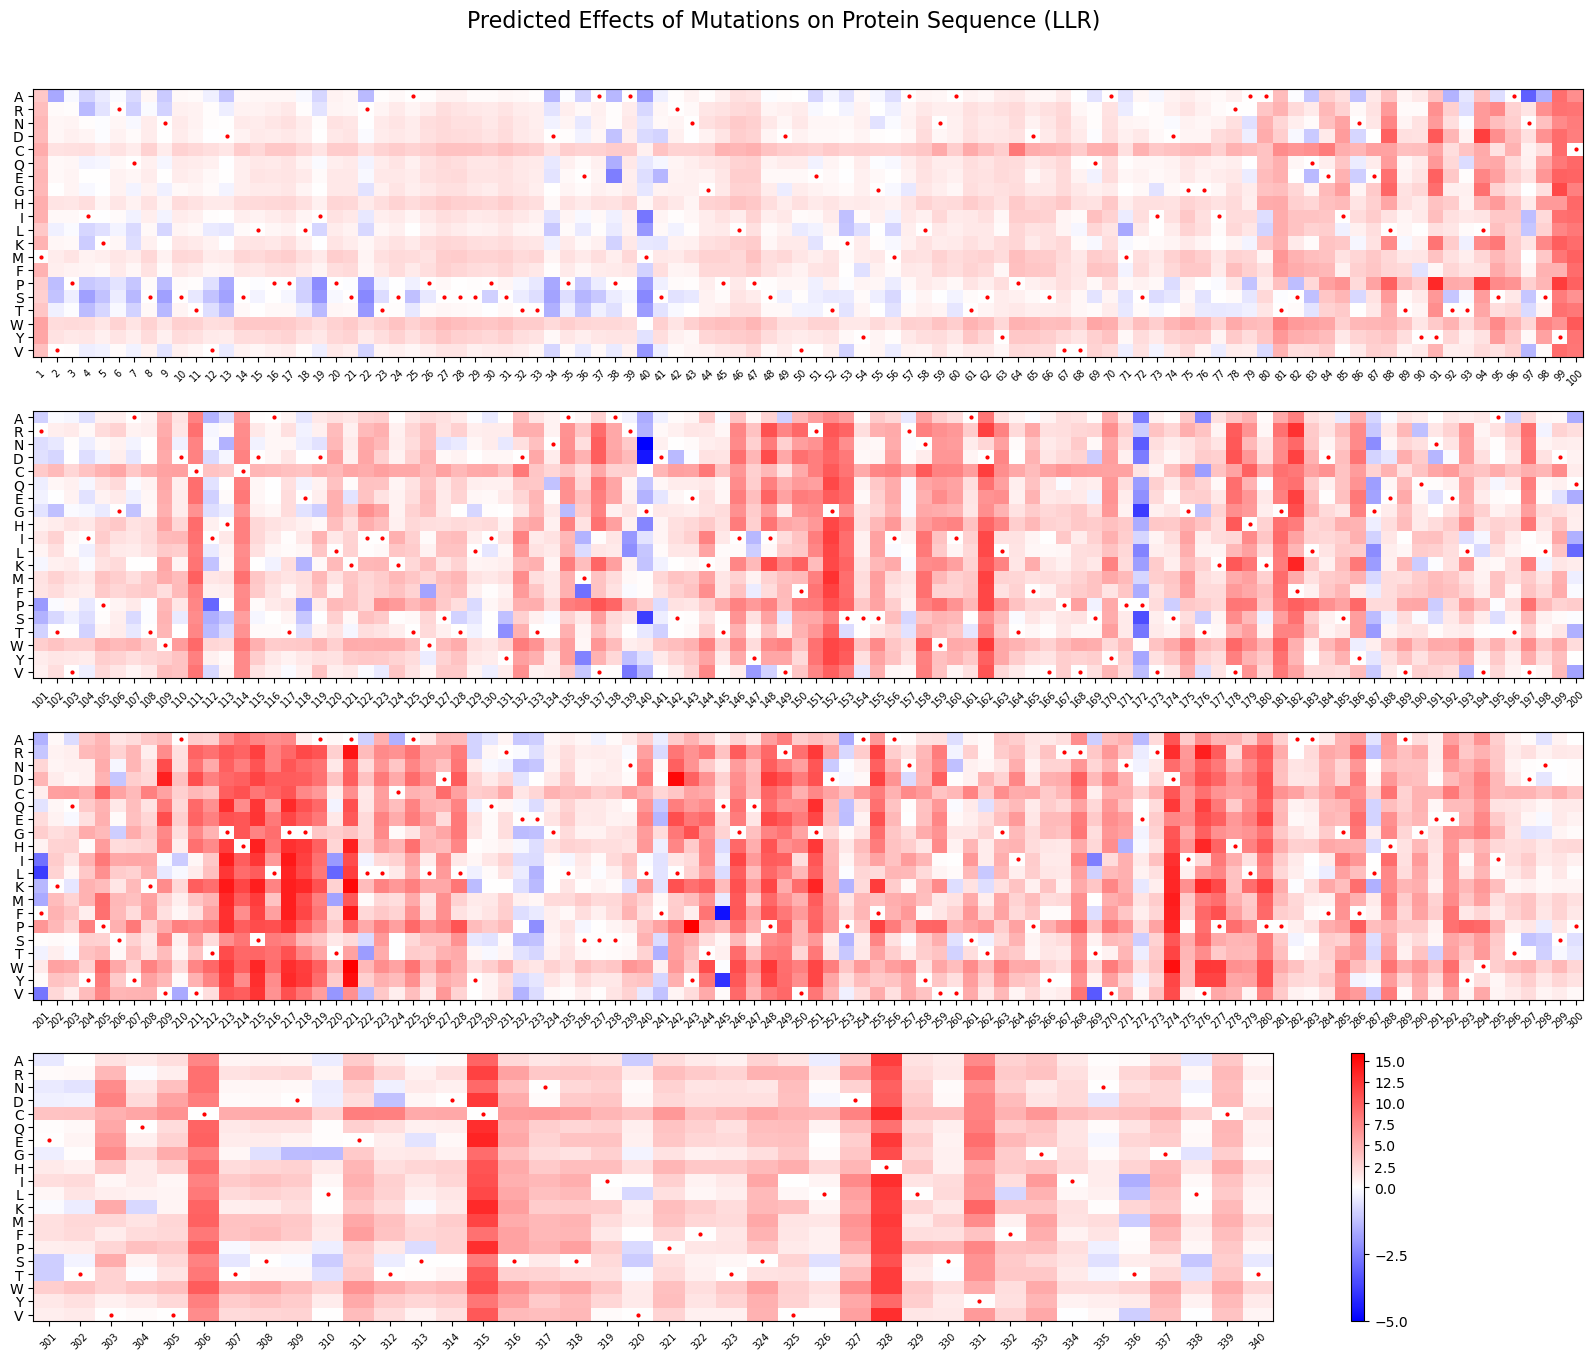

status: ok
encodings_dir: /Users/charmainechia/Documents/projects/ECOHARVEST/encodings
n_classical_features: 0
n_plm_features: 1
classical result keys: []
plm result keys: ['poet2_LLR']


In [5]:
# Section 1: Execute sequence encoding workflow.
result = get_sequence_encodings(user_inputs)

# Section 2: Print concise run summary.
print("status:", result.get("status", ""))
print("encodings_dir:", result.get("encodings_dir", ""))
print("n_classical_features:", len(result.get("feature_sets", {}).get("classical", [])))
print("n_plm_features:", len(result.get("feature_sets", {}).get("plm", [])))
print("classical result keys:", sorted(result.get("classical_results", {}).keys()))
print("plm result keys:", sorted(result.get("plm_results", {}).keys()))
